# C11 · Code walkthrough: `performance/flight_point.py`

**Track:** code walkthroughs. Every listing is printed from the repository with its real line numbers
(`show_source`). This notebook covers one module, line by line, because it is the coupling layer of the whole repo:
every hover, cruise, requirement and failure point of the Halo sizing is one call to `build_flight_point`.

| Module | Lines | What it holds |
|---|---|---|
| `performance/flight_point.py` | 454 | `FlightCondition`, `FlightPoint`, `RedundancyPointResult`, `ElectricalLayerResult`, `build_flight_point` (per-point Opti variables, equalities, inequalities, port values, margins) |

**What it imports:** `aerodynamics.slipstream.RotorState` (blown wing), `core.ports` (port-value dataclasses),
`powertrain.compatibility.operating_margins`, `powertrain.components.battery_ecm.EquivalentCircuitBattery` (root
selection branch), `powertrain.redundancy` (`degraded_state`, `battery_with_strings`), `thermal.heat` (`HeatLoad`,
`evaluate_point_thermal`).

**Who imports it (grep):** `mission/mission.py` (one point per segment or sub-segment), `mission/segments.py` and
`requirements/capability.py` (they build `FlightCondition`s), `trajectory/tiltrotor.py` and `trajectory/corridor.py`
(only `acceleration_gravity_m_s2`), `examples/halo_sizing.py`, `examples/coupled_sizing.py`,
`examples/requirements_sizing.py`, and seven test files under `tests/` (`performance/test_flight_point*.py`,
`test_hot_day_point.py`, `mission/test_mission_ecm.py`, `integration/test_halo_electrical.py`,
`powertrain/test_redundancy.py`, `trajectory/*`).

**The plan.** Thirteen listings cover lines 1-454 in order. After the setup chunk (L154-180) one cell rebuilds the
sized Halo and solves four points exactly as `examples/halo_sizing.py` builds them: the 4,000 ft hover requirement,
the first cruise sub-segment, a bus-out hover and an engine-out hover. Every later "Run it" cell reads intermediate
quantities from those solutions and checks them against hand formulas and against the cached baseline.

In [1]:
import sys
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(repo_root / "tutorials"))
from tutorial_helpers import *          # paths, plot style, check(), lb(), baseline(), capture_opti()

from dataclasses import replace
import aircraft_closure.performance.flight_point as fpm
from aircraft_closure.performance.flight_point import (FlightCondition, FlightPoint, build_flight_point,
                                                       acceleration_gravity_m_s2)
from aircraft_closure.core.margins import margin_report
from aircraft_closure.core.topology import connection_residuals
from aircraft_closure.powertrain.redundancy import degraded_state, battery_with_strings, redundancy_counts
from aircraft_closure.thermal.heat import coolant_temperatures_C
from examples.halo_sizing import HaloRequirements, build_halo_aircraft, build_halo_aerodynamics

ref, assumptions, requirements = baseline(), baseline_assumptions(), HaloRequirements()

---
## 1. Module docstring (L1-48)

The docstring is the specification. It grew one paragraph per tier, so it doubles as a change log.

In [2]:
show_source("src/aircraft_closure/performance/flight_point.py", 1, 48)

# src/aircraft_closure/performance/flight_point.py  lines 1-48
   1  """Quasi-steady flight points coupling aerodynamics and the series-hybrid powertrain.
   2  
   3  Orchestration layer: this module creates the per-point Opti variables (angle
   4  of attack, rotor speed, battery current, generator torque and, if not given,
   5  the electric power fraction) and the per-point equalities, because a flight
   6  point is a caller-side coupling of several disciplines. Components remain
   7  equation-only. The powertrain must be the series-hybrid reference topology
   8  (instances turboshaft, generator, battery, motor, gearbox, propulsor).
   9  
  10  Hover: thrust per active rotor = (T/W) W / ((1 - download) n_active) at zero
  11  airspeed; the download fraction belongs to the aerodynamics model.
  12  Airplane mode (tiltrotor cruise, rotors as propellers): wing lift = W cos(gamma),
  13  thrust = D + W sin(gamma), sin(gamma) = climb rate / V.
  14  
  15  Equivalent-circuit battery

**Line by line**

- **L1-8 role.** "Orchestration layer": this is the only place in the package where per-point `opti.variable(...)`
  and per-point `opti.subject_to(...)` calls are made. Components (motor, battery, rotor, ...) stay equation-only:
  they take numbers or CasADi expressions and return expressions (`docs/OPTIMIZATION_PHILOSOPHY.md`). L7-8 fix the
  topology: the instance names `turboshaft, generator, battery, motor, gearbox, propulsor` are looked up by name
  (L159-164), so the function only works on `build_series_hybrid` topologies.
- **L10-11 hover.** Thrust per active rotor = (T/W) W / ((1 - download) n_active), at zero airspeed. The download
  fraction comes from the aerodynamics model (decision 025, NDARC form in `aerodynamics/download.py`).
- **L12-13 airplane mode.** Lift = W cos(gamma), thrust = D + W sin(gamma), sin(gamma) = climb rate / V. Quasi-steady,
  no acceleration term.
- **L15-19 ECM battery (Tier 17, decision 021).** Current is held for `duration_s`; the bus voltage is the
  interval-mean terminal voltage. The power balance is the quadratic R_eff I^2 - V* I + P = 0, written as an
  equality; the inequality V >= V*/2 picks the low-current root (section 8).
- **L21-27 electrical layer (Tier 15, decision 023).** Inverter, cable, protection per motor and per generator; the
  battery feeder is protection + cable + optional DC/DC. The two power balances move to the bus side. Feeder currents
  use the bus voltage (first order). The battery feeder is exact.
- **L29-36 thermal (Tier 19, decision 028).** Named heat loads; fan power joins the bus demand in hover; cooling drag
  is a per-point variable in airplane mode, closed by an equality.
- **L38-47 redundancy (Tier 18, decision 032).** Lane motors share the rotor gearbox input torque; degraded states
  come from three Python integers on `FlightCondition`; they apply to every rotor alike; string contactors are in
  series with the pack; a failed bus feeds the others through a tie whose loss joins the demand.

The docstring's list of per-point variables (L3-5) predates Tier 19 and Tier 21: it omits the cooling-drag variable
(L208) and the blown-wing thrust variable (L195). Both are documented further down (L32-33, comment L193-194).

---
## 2. Imports and the gravity constant (L49-63)

In [3]:
show_source("src/aircraft_closure/performance/flight_point.py", 49, 63)

# src/aircraft_closure/performance/flight_point.py  lines 49-63
  49  from dataclasses import dataclass
  50  from typing import Any
  51  
  52  import aerosandbox as asb
  53  import aerosandbox.numpy as np
  54  
  55  from aircraft_closure.aerodynamics.slipstream import RotorState
  56  from aircraft_closure.core.ports import ElectricalPortValue, MechanicalPortValue
  57  from aircraft_closure.powertrain.compatibility import operating_margins
  58  from aircraft_closure.powertrain.components.battery_ecm import EquivalentCircuitBattery
  59  from aircraft_closure.powertrain.redundancy import battery_with_strings, degraded_state
  60  from aircraft_closure.thermal.heat import HeatLoad, evaluate_point_thermal
  61  
  62  acceleration_gravity_m_s2 = 9.80665
  63  


- **L52-53** `aerosandbox` and `aerosandbox.numpy`: `np.sqrt` dispatches to CasADi when its argument is symbolic,
  NumPy otherwise. That is what lets the same code build an Opti problem or evaluate numbers.
- **L55-60** one import per discipline the point couples: aero (only the `RotorState` container), ports, margins,
  the ECM class (for an `isinstance` branch, L238), redundancy and thermal.
- **L62** `acceleration_gravity_m_s2 = 9.80665`, the standard value. The trajectory modules import it from here, so
  the whole repo uses one g.

---
## 3. `FlightCondition` (L65-88)

In [4]:
show_source("src/aircraft_closure/performance/flight_point.py", 65, 88)

# src/aircraft_closure/performance/flight_point.py  lines 65-88
  65  @dataclass(frozen=True)
  66  class FlightCondition:
  67      mode: str = "airplane"
  68      velocity_m_s: Any = 60.0
  69      altitude_m: Any = 1000.0
  70      climb_rate_m_s: Any = 0.0
  71      thrust_to_weight: Any = 1.0
  72      active_rotor_count: Any = None
  73      active_generator_count: Any = None
  74      soc: Any = 0.8
  75      hybridization_electric: Any = None
  76      label: str = "point"
  77      # Tier 16: ambient temperature minus ISA at the (pressure) altitude; 0 is a standard day.
  78      temperature_offset_K: Any = 0.0
  79      # Tier 18 degraded states (Python integers): active lanes per rotor (None: all), active battery strings
  80      # (None: all) and failed buses (their lanes lost, their sources through a bus tie).
  81      active_lane_count: Any = None
  82      active_battery_string_count: Any = None
  83      count_buses_failed: int = 0
  84  
  85      def __post_init__(

**Line by line**

- **L65** `frozen=True`: conditions are values. Missions use `dataclasses.replace` to derive sub-segment conditions
  (`mission.py:100-101` renames the label to `"cruise 1/4"`).
- **L67** `mode`: `"hover"` or `"airplane"` (validated L85-87). There is no conversion mode here; conversion lives in
  the trajectory modules.
- **L68-71** `velocity_m_s`, `altitude_m`, `climb_rate_m_s`, `thrust_to_weight`: typed `Any`, so each can be an Opti
  variable. Halo's cruise speed is one (`halo_sizing.py`, `velocity_cruise_m_s=opti.variable(...)`).
  `thrust_to_weight` is read only in hover (L186).
- **L72-73** `active_rotor_count`, `active_generator_count`: `None` means all installed units (L165-166). The
  engine-out hover sets `active_generator_count = count - 1`.
- **L74** `soc`: start state of charge of the interval. Missions chain it.
- **L75** `hybridization_electric`: the battery share of the bus demand. `None` makes it a variable (L286-289); the
  sustained requirements fix it at 0 (`requirements/capability.py`).
- **L76** `label`: prefixes every margin label (L445).
- **L78** `temperature_offset_K`: ISA deviation at the pressure altitude (Tier 16, decision 020); it enters the
  atmosphere (L177) and through it density, engine lapse, speed of sound and cooling-air temperature.
- **L81-83** Tier 18 degraded state: active lanes per rotor, active battery strings, failed buses. Python integers,
  never symbolic: they change counts, so they change the structure of the problem.
- **L85-87** the only validation here. The degraded counts are validated later, in `degraded_state`.

**Run it**

In [5]:
print(FlightCondition())
try:
    FlightCondition(mode="cruise")
except ValueError as error:
    print("ValueError:", error)
hover_condition = requirements.requirement_set().hover.flight_condition()
print(hover_condition)
check("hover requirement: 4,000 ft, T/W 1.05, label 'hover', h_e free (None)",
      abs(hover_condition.altitude_m - 4000 * u.foot) < 1e-9 and hover_condition.thrust_to_weight == 1.05
      and hover_condition.label == "hover" and hover_condition.hybridization_electric is None)

FlightCondition(mode='airplane', velocity_m_s=60.0, altitude_m=1000.0, climb_rate_m_s=0.0, thrust_to_weight=1.0, active_rotor_count=None, active_generator_count=None, soc=0.8, hybridization_electric=None, label='point', temperature_offset_K=0.0, active_lane_count=None, active_battery_string_count=None, count_buses_failed=0)
ValueError: Unknown flight mode 'cruise'.
FlightCondition(mode='hover', velocity_m_s=0.0, altitude_m=1219.1999999999998, climb_rate_m_s=0.0, thrust_to_weight=1.05, active_rotor_count=None, active_generator_count=None, soc=0.8, hybridization_electric=None, label='hover', temperature_offset_K=0.0, active_lane_count=None, active_battery_string_count=None, count_buses_failed=0)
PASS  hover requirement: 4,000 ft, T/W 1.05, label 'hover', h_e free (None)


---
## 4. Result dataclasses (L90-152)

In [6]:
show_source("src/aircraft_closure/performance/flight_point.py", 90, 152)

# src/aircraft_closure/performance/flight_point.py  lines 90-152
  90  @dataclass(frozen=True)
  91  class FlightPoint:
  92      condition: Any
  93      weight_N: Any
  94      alpha_deg: Any
  95      aero: Any
  96      thrust_per_rotor_N: Any
  97      power_shaft_rotor_W: Any
  98      speed_rotor_rad_s: Any
  99      speed_motor_rad_s: Any
 100      torque_motor_Nm: Any
 101      power_electric_motors_W: Any
 102      hybridization_electric: Any
 103      battery: Any
 104      generator: Any
 105      engine: Any
 106      power_battery_W: Any
 107      fuel_flow_kg_s: Any
 108      margins: tuple
 109      heat_loads: tuple = ()                 # Tier 19: HeatLoad per loss source
 110      thermal: Any = None                    # Tier 19: PointThermal
 111      electrical: Any = None          # ElectricalLayerResult (Tier 15) or None without the electrical layer
 112      redundancy: Any = None          # RedundancyPointResult (Tier 18) or None without redundancy hardware or l

**Line by line**

- **L90-112 `FlightPoint`**, everything a caller may constrain or report.
  - `weight_N`, `alpha_deg` (None in hover), `aero` (None in hover), `thrust_per_rotor_N`;
  - `power_shaft_rotor_W` per rotor, `speed_rotor_rad_s`, `speed_motor_rad_s`, `torque_motor_Nm` (per lane);
  - `power_electric_motors_W`: total over active motors, on the bus side when the electrical layer exists;
  - `hybridization_electric`: the fixed value or the variable;
  - `battery`, `generator`, `engine`: the component result objects (per unit for generator and engine);
  - `power_battery_W`: the battery terminal power `battery.power_electric_W` (L451), before the string contactors
    and the feeder. The bus-side power is not stored on `FlightPoint`; it is in `electrical.power_battery_bus_W` with
    the layer, and otherwise only inside the function;
  - `fuel_flow_kg_s`: total over active engines (L452);
  - `margins`: operating plus thermal, already label-prefixed;
  - L109-112 defaults keep older callers working: `heat_loads=()`, `thermal=None`, `electrical=None`,
    `redundancy=None`.
- **L115-125 `RedundancyPointResult`.** Integers for the active state (L118-120), then the gearbox input torque per
  rotor (L121; the motor torque is this divided by active lanes), the string current per active string (L122), the
  total string-contactor loss (L123), the tie current and tie loss (L124-125). The tie fields are 0 in normal
  operation.
- **L128-151 `ElectricalLayerResult`.** Bus and battery voltages, the component results (inverters, cables, DC/DC),
  per-feeder bus powers (L139-141), loss totals over active instances (L142-145), heat loads (L146), and a derived
  `power_loss_total_W` (L148-151). A `@property` on a frozen dataclass is safe: it adds no field.

---
## 5. `build_flight_point`: signature and setup (L154-180)

In [7]:
show_source("src/aircraft_closure/performance/flight_point.py", 154, 180)

# src/aircraft_closure/performance/flight_point.py  lines 154-180
 154  def build_flight_point(opti, aircraft, aerodynamics, condition, mass_kg, hybridization_electric=None, *,
 155                         hybridization_electric_min=0.0,
 156                         drag_increments=(), duration_s=0.0, voltage_rc_start_V=None, temperature_start_C=None):
 157      topology = aircraft.powertrain.topology
 158      instances = topology.instances
 159      motor_model = instances["motor"].component
 160      generator_model = instances["generator"].component
 161      battery_model = instances["battery"].component
 162      gearbox_model = instances["gearbox"].component
 163      rotor_model = instances["propulsor"].component
 164      turboshaft_model = instances["turboshaft"].component
 165      active_rotor_count = condition.active_rotor_count or instances["propulsor"].count
 166      active_generator_count = condition.active_generator_count or instances["generator"].count
 167      # Ti

**Line by line**

- **L154-156 signature.** `opti` is the caller's problem: the point adds variables and constraints to it and never
  solves. `mass_kg` may be symbolic (MTOM is a design variable). `hybridization_electric` overrides the condition's
  value (L284-285). Keyword-only (after `*`): `hybridization_electric_min` (lower bound of the share when it is a
  variable; Halo passes -1 on free mission segments, decision 017), `drag_increments` (passed to aero),
  `duration_s` (ECM and thermal interval), `voltage_rc_start_V` (ECM RC state; None = steady polarization),
  `temperature_start_C` (dict by instance; None = steady temperatures).
- **L157-164** component lookup by instance name. The topology is a registry here; `connection_residuals` is never
  called (section 13 shows what it would return).
- **L165-166** active counts: `condition.x or installed count`. `or` treats 0 like None; a zero count is not a
  meaningful state, so this is harmless.
- **L168-170** `degraded_state` (`powertrain/redundancy.py:48-70`) returns active lanes per rotor (after removing a
  failed bus's lanes: lanes - failed x lanes / buses), active strings, failed buses and the installed counts.
  Active motors = active rotors x active lanes (L170).
- **L171-172** `has_strings`: string contactors exist. `has_redundancy`: any Tier 18 hardware, which decides whether
  a `RedundancyPointResult` is built (L363).
- **L173-174** the pack as connected at this point: with a string isolated, `battery_with_strings` scales the ECM
  parallel count by the active fraction (capacity, current rating, conductance, mass and so thermal capacitance all
  follow). `components_override` hands that pack to `evaluate_point_thermal` (L376) and to `operating_margins`
  (L440), so its limits and thermal state are the degraded ones.
- **L175** weight from mass with the module's g.
- **L177** one `asb.Atmosphere` for the point, with the ISA deviation; reused by rotor, engine, heat exchanger and
  margins.
- **L178-179** `has_cooling`: an installed heat exchanger. `drag_cooling_N` defaults to the float 0.0 so the thrust
  sum at L209 works without one.

**Run it: rebuild the sized Halo and solve four points the way `halo_sizing.py` builds them.**

- Hover requirement: the 4,000 ft, T/W 1.05 condition, `duration_s=60`, cold start
  (`coolant_temperatures_C`), h_e fixed to `baseline().hovers[0].hybridization` (`halo_sizing.py:1203-1206`).
- Cruise: the first of four cruise sub-segments (`subsegments_mission = (1, 1, 4, 1, 1, 1)`) at the cruise-start
  mass (MTOM minus take-off and climb fuel), the solved cruise speed, its duration, the SOC and the ECM RC voltages
  at the end of the climb (recomputed by chaining `pack.evaluate` from rest, as `build_mission` does), the machine
  temperatures at the end of the climb, and h_e fixed to the solved cruise value.
- Engine-out hover 1/3 and bus-out hover 1/3: sea level, T/W 1, MTOM, 20 s, SOC 0.30, steady polarization, start
  temperatures = end of the take-off hover (`halo_sizing.py:1214-1225`, `1432-1448`); h_e free in [0, 1].

With h_e fixed, each point has one free degree of freedom (rotor speed). The objective is the point's fuel flow.
At the hover requirement the tip-speed bound (L395) pins rotor speed (blade loading and rotor power bind at the same
point), so the solution is the baseline's. In the
two failure hovers the sizing chose h_e for the whole problem (SOC budget), which one point cannot see; we pin the
baseline's battery current (engine-out, from `engine_out_trace`) or battery heat (bus-out, from `thermal_trace`),
one equality, and the rest of the point must then reproduce.

In [8]:
aircraft = build_halo_aircraft(ref.design, requirements, assumptions)
aerodynamics = build_halo_aerodynamics(requirements, assumptions)
topology = aircraft.powertrain.topology
instances = {name: inst.component for name, inst in topology.instances.items()}
print({name: (type(inst.component).__name__, inst.count) for name, inst in topology.instances.items()})
print("bus count", topology.buses["bus"].count, "| redundancy counts", redundancy_counts(topology))

trace = {}
for row in ref.thermal_trace:                       # labels repeat ('climb' is a segment and a requirement)
    trace.setdefault(row["label"], row)

def solve_point(condition, mass_kg, pin=None, **kwargs):
    # One point in its own Opti: margins >= 0, minimum fuel flow; `pin(point)` adds equalities.
    opti = asb.Opti()
    point = build_flight_point(opti, aircraft, aerodynamics, condition, mass_kg, **kwargs)
    count_variables, count_constraints = opti.nx, opti.ng
    opti.subject_to([m.value >= -1e-7 for m in point.margins])
    if pin is not None:
        opti.subject_to(pin(point))
    opti.minimize(point.fuel_flow_kg_s * 100)
    solution = opti.solve(verbose=False)
    value = lambda x: scalar(solution.value(x))
    return point, solution, value, (count_variables, count_constraints)

# 1. hover requirement (halo_sizing.py:1203-1206)
cold_C = coolant_temperatures_C(aircraft.powertrain)
hover, hover_sol, hv, hover_size = solve_point(
    replace(hover_condition, hybridization_electric=ref.hovers[0].hybridization), ref.mass_takeoff_kg,
    duration_s=requirements.duration_hover_s, temperature_start_C=cold_C)

# 2. cruise 1/4 (build_mission chain: take-off hover from rest, climb, then cruise)
pack = instances["battery"]
rows = ref.battery_trace
take_off_battery = pack.evaluate(rows[0]["current_A"], rows[0]["soc_start"], rows[0]["duration_s"], (0.0, 0.0))
climb_battery = pack.evaluate(rows[1]["current_A"], rows[1]["soc_start"], rows[1]["duration_s"],
                              take_off_battery.voltage_rc_end_V)
mass_cruise_kg = ref.mass_takeoff_kg - ref.segments[0]["fuel_kg"] - ref.segments[1]["fuel_kg"]
cruise_condition = FlightCondition(velocity_m_s=ref.velocity_cruise_m_s, altitude_m=requirements.altitude_cruise_m,
                                   soc=rows[2]["soc_start"], hybridization_electric=ref.segments[2]["hybridization"],
                                   label="cruise 1/4")
cruise, cruise_sol, cv, cruise_size = solve_point(
    cruise_condition, mass_cruise_kg, duration_s=rows[2]["duration_s"],
    voltage_rc_start_V=climb_battery.voltage_rc_end_V, temperature_start_C=trace["climb"]["temperatures_end_C"])

# 3. engine-out hover 1/3 and 4. bus-out hover 1/3 (60 s split in three, SOC floor 0.30, steady polarization)
take_off_end_C = trace["take-off hover"]["temperatures_end_C"]
failure = dict(mode="hover", velocity_m_s=0.0, altitude_m=0.0, thrust_to_weight=1.0, soc=0.3)
row_eo = ref.engine_out_trace[0]
engine_out, engine_out_sol, ev, engine_out_size = solve_point(
    FlightCondition(label="engine-out hover 1/3", active_generator_count=1, **failure), ref.mass_takeoff_kg,
    pin=lambda p: p.battery.current_A / 1000 == row_eo["current_A"] / 1000,
    duration_s=20.0, voltage_rc_start_V=None, temperature_start_C=take_off_end_C)
heat_bus_out_battery_W = trace["bus-out hover 1/3"]["heat_W"]["battery"]
bus_out, bus_out_sol, bv, bus_out_size = solve_point(
    FlightCondition(label="bus-out hover 1/3", count_buses_failed=1, **failure), ref.mass_takeoff_kg,
    pin=lambda p: p.battery.power_loss_W / 1e4 == heat_bus_out_battery_W / 1e4,
    duration_s=20.0, voltage_rc_start_V=None, temperature_start_C=take_off_end_C)
for name, size in (("hover", hover_size), ("cruise 1/4", cruise_size), ("engine-out", engine_out_size),
                   ("bus-out", bus_out_size)):
    print(f"{name:<11} variables {size[0]}, constraints written by the point (incl. variable bounds) {size[1]}")

{'turboshaft': ('SimpleTurboshaft', 2), 'generator': ('Generator', 2), 'battery': ('EquivalentCircuitBattery', 1), 'motor': ('Motor', 4), 'gearbox': ('Gearbox', 2), 'propulsor': ('MomentumProfileRotor', 2), 'generator_gearbox': ('Gearbox', 2), 'protection_string': ('ProtectionUnit', 2), 'protection_bus_tie': ('ProtectionUnit', 1), 'cable_bus_tie': ('Cable', 1)}
bus count 2 | redundancy counts RedundancyCounts(count_lanes=2, count_buses=2, count_strings_battery=2, count_ties=1)


hover       variables 3, constraints written by the point (incl. variable bounds) 9
cruise 1/4  variables 6, constraints written by the point (incl. variable bounds) 18
engine-out  variables 4, constraints written by the point (incl. variable bounds) 11
bus-out     variables 4, constraints written by the point (incl. variable bounds) 11


In [9]:
for name, deg in (("normal", FlightCondition(mode="hover")),
                  ("bus out", FlightCondition(mode="hover", count_buses_failed=1)),
                  ("string out", FlightCondition(mode="hover", active_battery_string_count=1))):
    s = degraded_state(topology, deg)
    print(f"{name:<10} lanes/rotor {s.count_lanes_active}, strings {s.count_strings_active}, "
          f"buses failed {s.count_buses_failed}, fraction strings {s.fraction_strings_active}")
check("bus out: lanes per rotor = 2 - 1 x 2 // 2 = 1",
      degraded_state(topology, FlightCondition(mode="hover", count_buses_failed=1)).count_lanes_active == 1)
check("string out: pack parallel count halves (battery_with_strings)",
      abs(battery_with_strings(pack, 0.5).count_parallel - pack.count_parallel / 2) < 1e-12)
check("normal state: battery_with_strings returns the same object (no override)", battery_with_strings(pack, 1) is pack)
check("weight_N = mass x 9.80665", abs(hv(hover.weight_N) - ref.mass_takeoff_kg * 9.80665) < 1e-6)

normal     lanes/rotor 2, strings 2, buses failed 0, fraction strings 1.0
bus out    lanes/rotor 1, strings 2, buses failed 1, fraction strings 1.0
string out lanes/rotor 2, strings 1, buses failed 0, fraction strings 0.5
PASS  bus out: lanes per rotor = 2 - 1 x 2 // 2 = 1
PASS  string out: pack parallel count halves (battery_with_strings)
PASS  normal state: battery_with_strings returns the same object (no override)
PASS  weight_N = mass x 9.80665


---
## 6. Hover and airplane-mode branches (L181-212)

In [10]:
show_source("src/aircraft_closure/performance/flight_point.py", 181, 212)

# src/aircraft_closure/performance/flight_point.py  lines 181-212
 181      if condition.mode == "hover":
 182          alpha_deg, aero = None, None
 183          speed_rotor_rad_s = opti.variable(init_guess=100.0, scale=100.0, lower_bound=10.0)
 184          velocity_m_s = 0.0
 185          download_fraction = aerodynamics.hover_download_fraction(aircraft)
 186          thrust_total_N = condition.thrust_to_weight * weight_N / (1 - download_fraction)
 187      else:
 188          velocity_m_s = condition.velocity_m_s
 189          alpha_deg = opti.variable(init_guess=4.0, lower_bound=-5.0, upper_bound=20.0)
 190          speed_rotor_rad_s = opti.variable(init_guess=100.0, scale=100.0, lower_bound=10.0)
 191          rotor_state = None
 192          if getattr(aerodynamics, "blown_wing", None) is not None:
 193              # Tier 21 blown wing: the slipstream depends on thrust, thrust on drag. Thrust per rotor is a variable
 194              # tied to the drag by an equality below (no 

**Line by line, hover (L181-186)**

- **L182** no aerodynamics in hover: `alpha_deg` and `aero` are None. Wing lift is not credited.
- **L183** rotor speed variable: `init_guess=100.0, scale=100.0, lower_bound=10.0` (rad/s). The scale makes the
  variable O(1) for IPOPT (Halo rotors turn at 40-50 rad/s). The lower bound keeps the rotor model away from
  zero tip speed, where thrust coefficient T / (rho A (omega R)^2) blows up.
- **L184** V = 0, a float. The rotor model branches on `airplane_mode`, not on V.
- **L185-186** download from the aero model (NDARC strip form, decision 025):

$$T_{total} = \frac{(T/W)\,W}{1 - f_{DL}}$$

  because the rotors must lift the weight plus the download, which is itself f_DL x T_total.

**Line by line, airplane mode (L187-212)**

- **L189** angle of attack variable: `init_guess=4.0, lower_bound=-5.0, upper_bound=20.0` (deg), no scale (already
  O(1)). The bounds keep AeroBuildup in a sensible range.
- **L190** rotor speed variable, same as L183. It is created in both branches (not hoisted above the `if`).
- **L191-196 blown wing (Tier 21, decision 025).** The slipstream increments depend on the rotor thrust, and the
  thrust depends on the drag. Instead of iterating, thrust per rotor is a variable `init_guess=5000.0, scale=5000.0,
  lower_bound=0.0` (N), packed with the rotor-speed variable in a `RotorState` and passed to aero. The non-negative
  bound matches the momentum-theory slipstream, which needs T >= 0.
- **L197-198** aero evaluation at (V, h, alpha), with drag increments, ISA deviation and the rotor state. With
  `BuildupAerodynamics` this is AeroBuildup (symbolic through CasADi) plus the added items.
- **L199** sin(gamma) = climb rate / V.
- **L202** lift equality normalized by weight: L / W - cos(gamma) = 0, with cos(gamma) = sqrt(1 - sin^2). O(1) for
  any aircraft size (comment L200-201).
- **L203-205** stall inequality alpha <= alpha_stall. With `aero=aero` the buildup model returns
  alpha + (cl_max - CL) / CL_alpha (`buildup.py:115-120`), so the constraint is exactly CL <= cl_max at the point,
  without extra AeroBuildup runs.
- **L206-208 cooling drag (Tier 19, decision 028).** The exchanger's drag depends on the heat, the heat on the
  losses, the losses on thrust, thrust on drag. A variable `init_guess=100.0, scale=100.0, lower_bound=0.0` (N)
  breaks the loop; L383 closes it with an equality.
- **L209** required thrust = D + D_cooling + W sin(gamma).
- **L210-212** with the blown wing: equality (n T_rotor - T_required) / W = 0, then `thrust_total_N` is replaced by
  n T_rotor so the rotor model below sees the variable, not the drag expression. Both are equal at a solution; the
  substitution keeps the rotor's thrust input linear in one variable.

**Run it: hover thrust and the cruise equalities**

In [11]:
download = aerodynamics.hover_download_fraction(aircraft)
thrust_total_N = 1.05 * hv(hover.weight_N) / (1 - scalar(download))
print(f"download fraction {scalar(download):.4f}, total thrust {thrust_total_N:.0f} N, "
      f"per rotor {hv(hover.thrust_per_rotor_N):.0f} N, weight {hv(hover.weight_N):.0f} N")
check("hover: T_rotor = 1.05 W / ((1 - f_DL) x 2)", abs(hv(hover.thrust_per_rotor_N) - thrust_total_N / 2) < 1e-6)
check("hover: alpha and aero are None", hover.alpha_deg is None and hover.aero is None)

a = cruise.aero
drag_cooling_N = cv(cruise.thermal.cooling.drag_N)
print(f"cruise: alpha {cv(cruise.alpha_deg):.3f} deg, CL {cv(a.cl):.4f}, L/D {cv(a.lift_to_drag):.2f}, "
      f"D {cv(a.drag_N):.1f} N, cooling drag {drag_cooling_N:.3f} N, thrust/rotor {cv(cruise.thrust_per_rotor_N):.1f} N")
check("cruise: lift / weight = cos(gamma) = 1 (level)", abs(cv(a.lift_N / cruise.weight_N) - 1) < 1e-8)
check("cruise: blown-wing equality 2 T_rotor = D + D_cooling",
      abs(2 * cv(cruise.thrust_per_rotor_N) - cv(a.drag_N) - drag_cooling_N) < 1e-4)
alpha_stall = cv(aerodynamics.alpha_stall_deg(aircraft, ref.velocity_cruise_m_s, requirements.altitude_cruise_m,
                                              aero=a))
check("cruise: alpha <= alpha_stall (CL <= 1.5)", cv(cruise.alpha_deg) <= alpha_stall and cv(a.cl) <= 1.5)
check(f"cruise L/D reproduces the baseline ({ref.lift_to_drag_cruise:.3f})",
      abs(cv(a.lift_to_drag) / ref.lift_to_drag_cruise - 1) < 1e-4)

download fraction 0.0673, total thrust 76009 N, per rotor 38004 N, weight 67519 N
PASS  hover: T_rotor = 1.05 W / ((1 - f_DL) x 2)
PASS  hover: alpha and aero are None
cruise: alpha 6.640 deg, CL 0.8779, L/D 9.07, D 7382.0 N, cooling drag 2.938 N, thrust/rotor 3692.5 N
PASS  cruise: lift / weight = cos(gamma) = 1 (level)
PASS  cruise: blown-wing equality 2 T_rotor = D + D_cooling
PASS  cruise: alpha <= alpha_stall (CL <= 1.5)
PASS  cruise L/D reproduces the baseline (9.065)


---
## 7. Rotor, rotor limits, gearbox and the lane split (L214-232)

In [12]:
show_source("src/aircraft_closure/performance/flight_point.py", 214, 232)

# src/aircraft_closure/performance/flight_point.py  lines 214-232
 214      thrust_per_rotor_N = thrust_total_N / active_rotor_count
 215      if condition.mode == "airplane":
 216          rotor_model = rotor_model.in_airplane_mode()
 217      speed_motor_limit_rad_s = motor_model.max_speed_rad_s
 218      rotor = rotor_model.evaluate(velocity_m_s, atmosphere, thrust_N=thrust_per_rotor_N, speed_rad_s=speed_rotor_rad_s)
 219      # Rotor-speed physics models (Tier 12) return blade loading and helical tip Mach to bound.
 220      if getattr(rotor_model, "blade_loading_max", None) is not None:
 221          opti.subject_to(rotor.blade_loading <= rotor_model.blade_loading_max)
 222      if getattr(rotor_model, "mach_tip_helical_max", None) is not None:
 223          opti.subject_to(rotor.mach_tip_helical <= rotor_model.mach_tip_helical_max)
 224      if condition.mode == "airplane" and getattr(rotor_model, "advance_ratio_max", None) is not None:
 225          opti.subject_to(rotor.advance

**Line by line**

- **L214** thrust per active rotor. A rotor out (`active_rotor_count` lower) is symmetric multiplicity: the remaining
  rotors share the thrust; no roll trim.
- **L215-216** `in_airplane_mode()` returns a copy with `airplane_mode=True` (`rotor.py:81-82`), which switches the
  rotor model to axial-flight momentum plus the airplane-mode profile-drag increment.
- **L217** `speed_motor_limit_rad_s` is the motor's maximum speed; used at L392.
- **L218** the rotor model is called in **thrust mode**: thrust in, shaft power out, at the rotor-speed variable.
  For `MomentumProfileRotor` (Tier 12, decision 016): CT = T / (rho A (omega R)^2), induced power with kappa, profile
  power from a section-drag polar in blade loading CT/sigma.
- **L220-225 rotor-speed physics limits** (raw constraints, not margins: they never appear in a margin report), only if the model defines them (`getattr` keeps the actuator-disk rotor
  working):
  - blade loading CT/sigma <= 0.14 (stall margin; decision 016);
  - helical tip Mach sqrt((omega R)^2 + V^2) / a <= 0.80;
  - advance ratio V / (omega R) <= 0.60, airplane mode only (the model's validity edge).
  These three are not normalized; all are O(0.1-1) already.
- **L226** kinematics: motor speed = reduction ratio x rotor speed (ratio = input / output speed).
- **L227-228** gearbox input torque from the rotor power with the loss on torque:

$$Q_{in} = \frac{P_{rotor}}{\eta_{gb}\,\omega_{motor}}$$

  so P_in = P_rotor / eta and `Gearbox.evaluate` (`gearbox.py:81-88`) returns exactly omega_out x Q_out = P_rotor.
  Torque is computed from power, not iterated.
- **L230-231 lane split (Tier 18).** The active lanes of one rotor share Q_in equally. A failed lane is declutched,
  so it adds no loss (decision 032). The `if` avoids a division by one in the expression graph only.
- **L232** gearbox evaluated with the *total* input torque (one gearbox per rotor). Its loss is a heat load
  (L355).

**Run it: the mechanical chain of the hover requirement**

In [13]:
rotor, gearbox, motor = instances["propulsor"], instances["gearbox"], instances["motor"]
w_rotor, w_motor = hv(hover.speed_rotor_rad_s), hv(hover.speed_motor_rad_s)
p_rotor = hv(hover.power_shaft_rotor_W)
q_in = p_rotor / (scalar(gearbox.efficiency) * w_motor)
print(f"rotor {w_rotor:.3f} rad/s (tip {w_rotor * scalar(rotor.radius_m()):.1f} m/s), motor {w_motor:.2f} rad/s, "
      f"ratio {scalar(gearbox.reduction_ratio):.4f}, eta_gb {scalar(gearbox.efficiency):.5f}")
print(f"P_rotor {p_rotor / 1e3:.1f} kW, Q_in {q_in:.1f} N m, Q per lane {hv(hover.torque_motor_Nm):.1f} N m "
      f"(max {scalar(motor.max_torque_Nm):.0f})")
check("omega_motor = ratio x omega_rotor", abs(w_motor - scalar(gearbox.reduction_ratio) * w_rotor) < 1e-9)
check("Q_lane = P_rotor / (eta omega_motor) / 2 lanes", abs(hv(hover.torque_motor_Nm) - q_in / 2) < 1e-6)
check("RedundancyPointResult carries Q_in per rotor", abs(hv(hover.redundancy.torque_gearbox_input_Nm) - q_in) < 1e-6)
check(f"2 x P_rotor reproduces the baseline hover ({ref.hovers[0].power_rotors_W / 1e3:.1f} kW)",
      abs(2 * p_rotor / ref.hovers[0].power_rotors_W - 1) < 1e-6)
check("rotor power margin binds (P_rotor = max shaft power)", abs(p_rotor / scalar(rotor.max_shaft_power_W) - 1) < 1e-6)
atmosphere = asb.Atmosphere(altitude=hover_condition.altitude_m)
rotor_result = rotor.evaluate(0.0, atmosphere, thrust_N=hv(hover.thrust_per_rotor_N), speed_rad_s=w_rotor)
print(f"blade loading {scalar(rotor_result.blade_loading):.4f} (max 0.14), tip Mach {scalar(rotor_result.mach_tip_helical):.3f}")
check("hover blade loading at its 0.14 limit (baseline HoverSummary: 0.1400)",
      abs(scalar(rotor_result.blade_loading) - 0.14) < 1e-6 and abs(ref.hovers[0].blade_loading - 0.14) < 1e-6)
rc = instances["propulsor"].in_airplane_mode().evaluate(ref.velocity_cruise_m_s,
                                                        asb.Atmosphere(altitude=requirements.altitude_cruise_m),
                                                        thrust_N=cv(cruise.thrust_per_rotor_N),
                                                        speed_rad_s=cv(cruise.speed_rotor_rad_s))
print(f"cruise: advance ratio {scalar(rc.advance_ratio):.3f} (max 0.60), blade loading {scalar(rc.blade_loading):.4f}")
check(f"cruise advance ratio at its 0.60 limit (binding: {scalar(rc.advance_ratio) - 0.6:+.1e})",
      abs(scalar(rc.advance_ratio) - 0.6) < 1e-6)
check("hover tip speed at the design tip speed (L395 binding)",
      abs(w_rotor * scalar(rotor.radius_m()) / ref.design.speed_tip_m_s - 1) < 1e-6)

rotor 49.294 rad/s (tip 238.2 m/s), motor 223.23 rad/s, ratio 4.5285, eta_gb 0.97997
P_rotor 742.3 kW, Q_in 3393.4 N m, Q per lane 1696.7 N m (max 3000)
PASS  omega_motor = ratio x omega_rotor
PASS  Q_lane = P_rotor / (eta omega_motor) / 2 lanes
PASS  RedundancyPointResult carries Q_in per rotor
PASS  2 x P_rotor reproduces the baseline hover (1484.7 kW)
PASS  rotor power margin binds (P_rotor = max shaft power)
blade loading 0.1400 (max 0.14), tip Mach 0.709
PASS  hover blade loading at its 0.14 limit (baseline HoverSummary: 0.1400)
cruise: advance ratio 0.600 (max 0.60), blade loading 0.0462
PASS  cruise advance ratio at its 0.60 limit (binding: +1.0e-08)
PASS  hover tip speed at the design tip speed (L395 binding)


---
## 8. Battery current, ECM root selection, feeder and string drops, bus voltage (L234-263)

In [14]:
show_source("src/aircraft_closure/performance/flight_point.py", 234, 263)

# src/aircraft_closure/performance/flight_point.py  lines 234-263
 234      # With cooling (Tier 19) start at zero current: 50 A held through a long cruise drives the coulomb-counted SOC
 235      # chain far outside the cell data, and the battery loss there, through the exchanger's cubic pumping law,
 236      # swamps IPOPT. Without cooling the earlier 50 A start is kept (reference results unchanged).
 237      current_battery_A = opti.variable(init_guess=0.0 if has_cooling else 50.0, scale=100.0)
 238      if isinstance(battery_model, EquivalentCircuitBattery):
 239          battery = battery_model.evaluate(current_battery_A, condition.soc, duration_s, voltage_rc_start_V)
 240          # Low-current root of R_eff I^2 - V* I + P = 0; also P <= V*^2 / (4 R_eff).
 241          opti.subject_to(battery.voltage_V / battery.voltage_driving_V >= 0.5)
 242      else:
 243          battery = battery_model.evaluate(current_battery_A, condition.soc)
 244      has_layer = "inverter_motor" in ins

**Line by line**

- **L234-237 battery current variable**, `scale=100.0`, no bounds (negative current = charging, positive =
  discharge). `init_guess` is 0 A with a heat exchanger and 50 A without. The comment gives the reason (decision
  028, "Starting point"): 50 A held through a 2.4 h cruise moves the coulomb-counted SOC chain outside the cell data,
  and the battery loss feeds the exchanger's cubic pumping law, which made the first IPOPT iterations blow up. 50 A is
  kept without cooling so older reference results are unchanged.
- **L238-241 ECM branch.** `evaluate(I, soc, duration, rc_start)` returns the interval-mean terminal voltage
  V = V* - I R_eff, where V* (`voltage_driving_V`) is OCV minus the decaying RC start offsets and R_eff is R0 plus
  the RC slopes (`battery_ecm.py:273-307`). The terminal power P = V I gives

$$R_{eff} I^2 - V^* I + P = 0, \qquad I = \frac{V^* \mp \sqrt{V^{*2} - 4 R_{eff} P}}{2 R_{eff}}$$

  Both roots deliver the same power. The high-current root (V < V*/2) is the wrong side of the power peak
  P_max = V*^2 / (4 R_eff). L241 writes V / V* >= 0.5, which is V >= V*/2: it excludes the high root and also
  implies P <= P_max. Normalized by V*, O(1). Decision 021 records that from a high-root start IPOPT reports local
  infeasibility rather than returning the wrong root.
- **L242-243** constant battery (`Battery`): no duration, no root problem (its quadratic is solved in closed form
  inside).
- **L244-246** `has_layer`: the topology has `inverter_motor` (Tier 15). `layer` is a name -> component dict of all
  instances. `dcdc_model` exists only with the layer.
- **L247-250** series resistance of the battery feeder: cable + protection unit, with the layer.
- **L251-255 string contactors (Tier 18).** Each string has a contactor in series; the active ones are in parallel.
  String current = I / S_active (L253). Equivalent series resistance R_string / S_active (L255). The contactor
  result (L254) gives the per-contactor loss.
- **L256-261** with any feeder resistance:
  - L257-258 total series resistance. Note: `r[0] if len == 1 else r[0] + r[1]` is `sum(r)` written out (the list has
    at most two entries);
  - L260 exact series drop at the battery current: V_feeder = V_terminal - I R_series;
  - L261 bus voltage: the DC/DC output setpoint if there is one, else V_feeder.
- **L262-263** no feeder: the bus is the battery terminal.

**Run it: the hover battery and its two roots**

I 779.55 A, V 739.54 V, V* 830.20 V, R_eff 116.30 mOhm, P 576.5 kW, V/V* 0.8908
roots: low 779.55 A, high 6359 A; P_max 1.48 MW at 3569 A
PASS  V = V* - I R_eff (interval mean)
PASS  solution is the low root
PASS  branch constraint V/V* >= 0.5 holds with room
PASS  hover battery power reproduces the baseline (576.5 kW)
string contactor R 0.4268 mOhm each, 2 in parallel; bus voltage 739.369 V (drop 0.1664 V)
PASS  bus voltage = V_terminal - I R_string / 2 (motor port voltage)
PASS  string current = I / 2


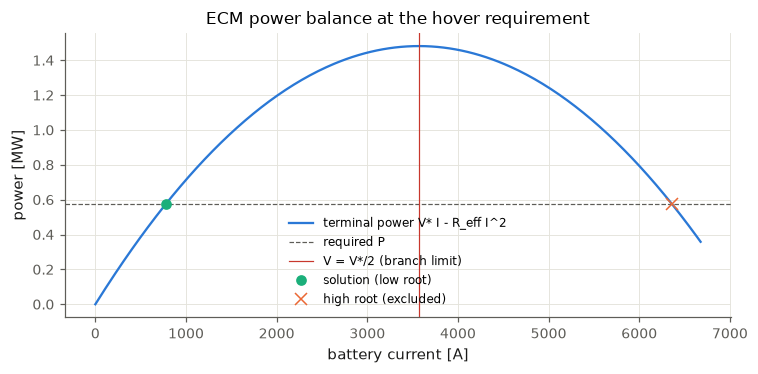

In [15]:
b = hover.battery
I, V, V_star, R_eff = hv(b.current_A), hv(b.voltage_V), hv(b.voltage_driving_V), hv(b.resistance_effective_ohm)
P = hv(b.power_electric_W)
disc = np.sqrt(V_star**2 - 4 * R_eff * P)
I_low, I_high = (V_star - disc) / (2 * R_eff), (V_star + disc) / (2 * R_eff)
print(f"I {I:.2f} A, V {V:.2f} V, V* {V_star:.2f} V, R_eff {R_eff * 1e3:.2f} mOhm, P {P / 1e3:.1f} kW, V/V* {V / V_star:.4f}")
print(f"roots: low {I_low:.2f} A, high {I_high:.0f} A; P_max {V_star**2 / (4 * R_eff) / 1e6:.2f} MW at {V_star / (2 * R_eff):.0f} A")
check("V = V* - I R_eff (interval mean)", abs(V - (V_star - I * R_eff)) < 1e-8)
check("solution is the low root", abs(I - I_low) < 1e-6)
check("branch constraint V/V* >= 0.5 holds with room", V / V_star > 0.5)
check(f"hover battery power reproduces the baseline ({ref.hovers[0].power_battery_W / 1e3:.1f} kW)",
      abs(P / ref.hovers[0].power_battery_W - 1) < 1e-6)

R_string = scalar(instances["protection_string"].resistance_ohm())
V_bus = V - I * R_string / 2
print(f"string contactor R {R_string * 1e3:.4f} mOhm each, 2 in parallel; bus voltage {V_bus:.3f} V (drop {V - V_bus:.4f} V)")
check("bus voltage = V_terminal - I R_string / 2 (motor port voltage)",
      abs(scalar(hover_sol.value(hover.generator.current_A)) * V_bus - hv(hover.generator.power_electric_W)) < 1e-4)
check("string current = I / 2", abs(hv(hover.redundancy.current_string_A) - I / 2) < 1e-9)

currents = np.linspace(0, 1.05 * I_high, 300)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(currents, (V_star * currents - R_eff * currents**2) / 1e6, color=blue, label="terminal power V* I - R_eff I^2")
ax.axhline(P / 1e6, color=ink_muted, lw=0.8, ls="--", label="required P")
ax.axvline(V_star / (2 * R_eff), color=red, lw=0.8, label="V = V*/2 (branch limit)")
ax.plot([I_low], [P / 1e6], "o", color=aqua, label="solution (low root)")
ax.plot([I_high], [P / 1e6], "x", color=orange, ms=8, label="high root (excluded)")
ax.set_xlabel("battery current [A]"); ax.set_ylabel("power [MW]"); ax.legend(loc="lower center", fontsize=8)
ax.set_title("ECM power balance at the hover requirement"); plt.tight_layout(); plt.show()

---
## 9. Motors, motor feeders and the bus tie (L264-283)

In [16]:
show_source("src/aircraft_closure/performance/flight_point.py", 264, 283)

# src/aircraft_closure/performance/flight_point.py  lines 264-283
 264      motor = motor_model.evaluate(speed_motor_rad_s, torque_motor_Nm, voltage_bus_V)
 265      power_electric_motors_W = count_motors_active * motor.power_electric_W
 266      if has_layer:
 267          inverter_motor = layer["inverter_motor"].evaluate(motor.power_electric_W, voltage_bus_V)
 268          current_motor_feeder_A = inverter_motor.power_dc_W / voltage_bus_V
 269          cable_motor = layer["cable_motor"].evaluate(current_motor_feeder_A)
 270          protection_motor = layer["protection_motor"].evaluate(current_motor_feeder_A)
 271          power_motor_bus_W = inverter_motor.power_dc_W + cable_motor.power_loss_W + protection_motor.power_loss_W
 272          power_electric_motors_W = count_motors_active * power_motor_bus_W
 273      # Tier 18 bus tie: a failed bus's sources feed the others through one tie (normally open: no current).
 274      current_tie_A, power_loss_tie_W, tie_ports = 0.0, 0.0, {}
 

**Line by line**

- **L264** motor at (omega_motor, Q_lane, V_bus). P_el = omega Q + P_loss (McDonald map, decision 005); current
  = P_el / V_bus.
- **L265** bus demand = active motors x P_el. Without the layer this is the machine's DC power (the inverter is
  folded into the machine mass and efficiency).
- **L266-272 electrical layer.** Per motor feeder:
  - L267 inverter at the motor's AC power (the motor's electrical power), DC-link at the bus voltage;
  - L268 feeder current = inverter DC power / V_bus (first order: the cable drop is not subtracted);
  - L269-270 cable and protection at that current, losses I^2 R;
  - L271 power drawn from the bus per feeder = P_dc + cable loss + protection loss;
  - L272 the demand is now on the bus side.
- **L273-283 bus tie (Tier 18).** `count_ties` > 0 means cross-strapped buses with normally open ties.
  - L276-281 only with a failed bus: the failed bus's sources (1/B of the generators and strings) reach the
    surviving bus through one tie, so

$$I_{tie} = \frac{n_{failed}\, P_{motors}}{B\, V_{bus}}$$

    with P_motors the motor feeders' demand. Tie loss = contactor + cable I^2 R.
  - L282-283 tie port values are written in every state (current 0 when no bus failed), because
    `operating_margins` needs a value for every instance's port. Their margins are removed again in normal
    operation (L441-444).

Decision 032 states "tie current = (motor and fan demand) / B / bus voltage". The code uses
`power_electric_motors_W` only; the fan power is added to the demand later (L381). With fan powers of 50-400 W
against 1.3 MW of motor demand the difference is below 0.03 % of the tie current. It is listed under Findings.

**Run it: the bus-out tie**

In [17]:
red = bus_out.redundancy
P_motors_bo, V_bus_bo = bv(bus_out.power_electric_motors_W), bv(bus_out.battery.voltage_V) - bv(bus_out.battery.current_A) * R_string / 2
I_tie = bv(red.current_tie_A)
R_tie = scalar(instances["protection_bus_tie"].resistance_ohm()) + scalar(instances["cable_bus_tie"].resistance_ohm())
print(f"bus out: lanes/rotor {red.count_lanes_active}, motors active {2 * red.count_lanes_active}, "
      f"P_motors {P_motors_bo / 1e3:.1f} kW, V_bus {V_bus_bo:.2f} V")
print(f"I_tie {I_tie:.1f} A, tie loss {bv(red.power_loss_tie_W):.1f} W (R_tie {R_tie * 1e3:.4f} mOhm)")
check("I_tie = 1 x P_motors / (2 buses x V_bus)", abs(I_tie - P_motors_bo / (2 * V_bus_bo)) < 1e-6)
check("tie loss = I_tie^2 (R_contactor + R_cable)", abs(bv(red.power_loss_tie_W) - I_tie**2 * R_tie) < 1e-6)
check("tie heat loads reproduce the baseline trace",
      abs(bv(red.power_loss_tie_W) - trace["bus-out hover 1/3"]["heat_W"]["protection_bus_tie"]
          - trace["bus-out hover 1/3"]["heat_W"]["cable_bus_tie"]) < 1e-3)
check("normal hover: tie current 0", hover.redundancy.current_tie_A == 0.0)

bus out: lanes/rotor 1, motors active 2, P_motors 1403.3 kW, V_bus 692.37 V
I_tie 1013.4 A, tie loss 216.7 W (R_tie 0.2110 mOhm)
PASS  I_tie = 1 x P_motors / (2 buses x V_bus)
PASS  tie loss = I_tie^2 (R_contactor + R_cable)
PASS  tie heat loads reproduce the baseline trace
PASS  normal hover: tie current 0


---
## 10. Hybridization, generator at peak-efficiency speed, generator and battery feeders (L284-338)

In [18]:
show_source("src/aircraft_closure/performance/flight_point.py", 284, 338)

# src/aircraft_closure/performance/flight_point.py  lines 284-338
 284      if hybridization_electric is None:
 285          hybridization_electric = condition.hybridization_electric
 286      if hybridization_electric is None:
 287          # A negative share means the generators also recharge the battery (bounded by its charge rating).
 288          hybridization_electric = opti.variable(init_guess=0.3 if hybridization_electric_min >= 0 else 0.0,
 289                                                 lower_bound=hybridization_electric_min, upper_bound=1.0)
 290      speed_generator_rad_s = generator_model.loss_model.speed_peak_efficiency_rad_s
 291      torque_generator_Nm = opti.variable(init_guess=500.0, scale=500.0, lower_bound=0.0)
 292      generator = generator_model.evaluate(speed_generator_rad_s, torque_generator_Nm, voltage_bus_V)
 293      electrical = None
 294      power_battery_bus_W = battery.power_electric_W
 295      if has_strings and not has_layer:
 296          power

**Line by line**

- **L284-289 hybridization.** Priority: the function argument, then the condition, then a variable. The variable
  has `lower_bound=hybridization_electric_min, upper_bound=1.0`, no scale (O(1)). `init_guess` is 0.3 when charging
  is not allowed and 0 when it is (min < 0): a free mission segment starts with no battery use (decision 017).
  A negative share means the generators also recharge the pack (L287).
- **L290 generator speed = its own peak-efficiency speed** (the McDonald point omega_hat). This is a modelling
  choice, not a variable: the engine (fixed-speed output shaft at the deck's 1,210 rpm) and the step-up ratio are
  sized so that omega_hat x ratio = engine speed (`halo_sizing.py:739`). Generator speed is a design variable of
  the sizing (Tier 13, decision 018), not a per-point one.
- **L291 generator torque variable**: `init_guess=500.0, scale=500.0, lower_bound=0.0` (N m). Non-negative:
  generating quadrant only.
- **L292** generator at (omega_hat, Q, V_bus). P_el = omega Q - P_loss; current positive out of the machine.
- **L293-297 defaults without the layer.** Battery bus power = battery terminal power (L294); with strings but no
  layer it is V_feeder x I (L295-296), i.e. terminal power minus the string-contactor loss I^2 R_string / S.
  Generator bus power = generator electrical power (L297).
- **L298-338 electrical layer.**
  - L300 the generator's inverter works as an active rectifier: it receives negative AC power (AC -> DC is
    negative in the inverter sign convention, `converters.py:40`);
  - L301 feeder current = -P_dc / V_bus (positive towards the bus);
  - L302-305 generator bus power = -P_dc - cable loss - protection loss;
  - L306-308 battery feeder: cable and protection at the battery current; feeder power V_feeder x I (exact);
  - L309-315 optional DC/DC: input the feeder power at V_feeder, output to the bus at its setpoint; its loss is
    tracked;
  - L316-338 `ElectricalLayerResult`: totals multiply per-unit losses by active counts (motors, generators); heat
    loads are one `HeatLoad` per instance with its active count (L329-338), the DC/DC appended only if present.

**Run it: generator and engine speed, and the electrical layer (not in the baseline)**

The baseline has the layer off (`electrical_layer=False`). To exercise L244-272 and L298-338 we rebuild the same
design with the layer on, with and without the DC/DC, and solve the same hover requirement.

In [19]:
generator, step_up = instances["generator"], instances["generator_gearbox"]
w_gen = scalar(generator.loss_model.speed_peak_efficiency_rad_s)
print(f"generator speed {w_gen:.2f} rad/s = design speed_peak_generator {ref.design.speed_peak_generator_rad_s:.2f}; "
      f"generator torque {hv(hover.generator.power_shaft_W) / w_gen:.1f} N m")
check("generator runs at its McDonald peak-efficiency speed", abs(w_gen - ref.design.speed_peak_generator_rad_s) < 1e-9)
check("h_e fixed: the point returns the given float", hover.hybridization_electric == ref.hovers[0].hybridization)
check("failure hovers: h_e is a variable within [0, 1]",
      not isinstance(engine_out.hybridization_electric, float) and 0 <= ev(engine_out.hybridization_electric) <= 1)

def layer_hover(dcdc):
    a = replace(assumptions, electrical_layer=True, dcdc_converter=dcdc)
    craft = build_halo_aircraft(ref.design, requirements, a)
    opti = asb.Opti()
    point = build_flight_point(opti, craft, build_halo_aerodynamics(requirements, a),
                               replace(hover_condition, hybridization_electric=ref.hovers[0].hybridization),
                               ref.mass_takeoff_kg, duration_s=60.0, temperature_start_C=coolant_temperatures_C(craft.powertrain))
    opti.minimize(point.fuel_flow_kg_s * 100)
    solution = opti.solve(verbose=False)
    return craft, point, (lambda x: scalar(solution.value(x)))

for dcdc in (False, True):
    craft, p, lv = layer_hover(dcdc)
    e, layer = p.electrical, {n: i.component for n, i in craft.powertrain.topology.instances.items()}
    R_feed = (scalar(layer["cable_battery"].resistance_ohm()) + scalar(layer["protection_battery"].resistance_ohm())
              + scalar(layer["protection_string"].resistance_ohm()) / 2)
    V_feed = lv(e.voltage_battery_V) - lv(p.battery.current_A) * R_feed
    print(f"layer, dcdc={dcdc}: V_bus {lv(e.voltage_bus_V):.2f} V, V_battery {lv(e.voltage_battery_V):.2f} V; losses kW: "
          f"inverters {lv(e.power_loss_inverters_W) / 1e3:.2f}, cables {lv(e.power_loss_cables_W) / 1e3:.2f}, "
          f"protection {lv(e.power_loss_protection_W) / 1e3:.3f}, dcdc {lv(e.power_loss_dcdc_W) / 1e3:.2f}")
    if not dcdc:
        check("layer: V_bus = V_terminal - I (R_cable + R_protection + R_string/2)", abs(lv(e.voltage_bus_V) - V_feed) < 1e-8)
    else:
        check("layer + DC/DC: bus held at the 800 V setpoint", abs(lv(e.voltage_bus_V) - 800.0) < 1e-9)
        check("DC/DC: bus power = feeder power - converter loss",
              abs(lv(e.power_battery_bus_W) - (V_feed * lv(p.battery.current_A) - lv(e.power_loss_dcdc_W))) < 1e-4)
    P_motor_bus = lv(e.inverter_motor.power_dc_W) + lv(e.cable_motor.power_loss_W) + lv(layer["protection_motor"].evaluate(
        lv(e.inverter_motor.power_dc_W) / lv(e.voltage_bus_V)).power_loss_W)
    check(f"layer (dcdc={dcdc}): motor feeder bus power = P_dc + cable + protection", abs(lv(e.power_motor_bus_W) - P_motor_bus) < 1e-6)
    check(f"layer (dcdc={dcdc}): rectifier sees negative AC power", lv(e.inverter_generator.power_ac_W) < 0)
    check(f"layer (dcdc={dcdc}): same rotor power as without the layer", abs(lv(p.power_shaft_rotor_W) / p_rotor - 1) < 1e-8)

generator speed 580.46 rad/s = design speed_peak_generator 580.46; generator torque 900.7 N m
PASS  generator runs at its McDonald peak-efficiency speed
PASS  h_e fixed: the point returns the given float
PASS  failure hovers: h_e is a variable within [0, 1]
layer, dcdc=False: V_bus 736.93 V, V_battery 737.61 V; losses kW: inverters 35.65, cables 1.90, protection 0.527, dcdc 0.00
PASS  layer: V_bus = V_terminal - I (R_cable + R_protection + R_string/2)
PASS  layer (dcdc=False): motor feeder bus power = P_dc + cable + protection
PASS  layer (dcdc=False): rectifier sees negative AC power
PASS  layer (dcdc=False): same rotor power as without the layer


layer, dcdc=True: V_bus 800.00 V, V_battery 735.26 V; losses kW: inverters 34.99, cables 2.38, protection 0.648, dcdc 11.13
PASS  layer + DC/DC: bus held at the 800 V setpoint


PASS  DC/DC: bus power = feeder power - converter loss
PASS  layer (dcdc=True): motor feeder bus power = P_dc + cable + protection
PASS  layer (dcdc=True): rectifier sees negative AC power
PASS  layer (dcdc=True): same rotor power as without the layer


---
## 11. Step-up gearbox, engine, heat loads, redundancy result, thermal (L339-376)

In [20]:
show_source("src/aircraft_closure/performance/flight_point.py", 339, 376)

# src/aircraft_closure/performance/flight_point.py  lines 339-376
 339      # Optional step-up gearbox between turboshaft output and generator (Tier 13): ratio = input / output speed.
 340      speed_engine_rad_s, torque_engine_Nm = speed_generator_rad_s, torque_generator_Nm
 341      generator_gear_ports = {}
 342      if "generator_gearbox" in instances:
 343          generator_gearbox_model = instances["generator_gearbox"].component
 344          speed_engine_rad_s = speed_generator_rad_s * generator_gearbox_model.reduction_ratio
 345          torque_engine_Nm = torque_generator_Nm / (generator_gearbox_model.reduction_ratio * generator_gearbox_model.efficiency)
 346          generator_gear = generator_gearbox_model.evaluate(speed_engine_rad_s, torque_engine_Nm)
 347          generator_gear_ports = {
 348              "generator_gearbox.shaft_in": MechanicalPortValue(speed_engine_rad_s, torque_engine_Nm),
 349              "generator_gearbox.shaft_out": MechanicalPortValue(generator_

**Line by line**

- **L340-341** defaults without a step-up gearbox: the engine shaft is the generator shaft.
- **L342-351 step-up gearbox (Tier 13, decision 018).** `reduction_ratio` = input / output speed = engine /
  generator speed, below 1 for a step-up (0.218 here). Engine speed = omega_gen x ratio (L344). Engine torque from
  the generator torque with the loss on torque, Q_eng = Q_gen / (ratio x eta) (L345), the mirror of L228: then
  `Gearbox.evaluate(omega_eng, Q_eng)` returns omega_gen and Q_gen exactly. L347-351 port values for the margins.
- **L352** engine: `evaluate(shaft power, atmosphere)` gives fuel flow from the part-power thermal efficiency at the
  point's power available (lapse with density and temperature, decision 012/014/020).
- **L353-361 heat loads (Tier 19).** One `HeatLoad(source, per-unit power, active count)` per loss source: motor
  (active motors), rotor gearbox (active rotors), generator and step-up gearbox (active generators), battery (1),
  then the electrical layer's loads. `thermal/heat.py` never lists sources: a new loss is one more `HeatLoad` here
  (comment L353). The engine's heat is not a load (it leaves in the exhaust).
- **L362-374 redundancy result.** String loss total = active strings x per-contactor loss (L364); string and tie
  heat loads (L365-369); the `RedundancyPointResult` (L370-374). `protection_string`, `protection_tie` and
  `cable_tie` are only bound inside earlier `if` blocks; the same conditions guard their use here, so there is no
  unbound name.
- **L375-376** `evaluate_point_thermal`: for each load with a thermal model (motor, generator, battery here), the
  first-order temperature at the end of the interval from the start temperature, the interval-mean heat to the
  coolant, and a temperature margin; then the heat exchanger at the interval-mean rejected heat (gearboxes are
  excluded: `sources_excluded_heat_exchanger`), with fan power in hover or drag in airplane mode, and its rating
  margin. `components=components_override` gives a degraded pack its own capacitance and resistance.

**Run it: engine chain and heat loads**

In [21]:
print(f"engine speed {w_gen * scalar(step_up.reduction_ratio):.3f} rad/s = {w_gen * scalar(step_up.reduction_ratio) / (2 * np.pi / 60):.1f} rpm "
      f"(deck 1,210 rpm); step-up ratio {scalar(step_up.reduction_ratio):.5f}, eta {scalar(step_up.efficiency):.5f}")
check("engine speed = omega_gen x ratio = 1,210 rpm",
      abs(w_gen * scalar(step_up.reduction_ratio) - 1210 * 2 * np.pi / 60) < 1e-6)
check("engine shaft power = generator shaft power / eta_step_up",
      abs(hv(hover.engine.power_shaft_W) - hv(hover.generator.power_shaft_W) / scalar(step_up.efficiency)) < 1e-6)
check("fuel flow = 2 active engines x per-engine fuel flow",
      abs(hv(hover.fuel_flow_kg_s) - 2 * hv(hover.engine.fuel_flow_kg_s)) < 1e-12)

for label, point, value in (("hover", hover, hv), ("cruise 1/4", cruise, cv), ("engine-out hover 1/3", engine_out, ev),
                            ("bus-out hover 1/3", bus_out, bv)):
    ours = {load.source: value(load.total_W()) for load in point.heat_loads}
    base = trace[label]["heat_W"]
    worst = max(abs(ours[k] - base[k]) / max(abs(base[k]), 1.0) for k in base)
    temps = {k: round(value(t), 2) for k, t in point.thermal.temperatures_end_C.items()}
    print(f"{label:<21} heat kW " + ", ".join(f"{k} {v / 1e3:.2f}" for k, v in ours.items()))
    print(f"{'':<21} end temperatures {temps}; fan {value(point.thermal.cooling.power_fan_W):.1f} W, "
          f"cooling drag {value(point.thermal.cooling.drag_N):.3f} N")
    check(f"{label}: heat by source reproduces the baseline (max rel. error {worst:.1e})",
          set(ours) == set(base) and worst < 1e-3)
    check(f"{label}: end temperatures reproduce the baseline",
          max(abs(value(t) - trace[label]["temperatures_end_C"][k]) for k, t in point.thermal.temperatures_end_C.items()) < 1e-2)
check("counts: motor heat = 4 lanes x per-unit loss in normal hover",
      [l.count for l in hover.heat_loads if l.source == "motor"] == [4])
check("bus out: 2 active motors and the two tie loads appear",
      [l.count for l in bus_out.heat_loads if l.source == "motor"] == [2]
      and {"protection_bus_tie", "cable_bus_tie"} <= {l.source for l in bus_out.heat_loads})

engine speed 126.711 rad/s = 1210.0 rpm (deck 1,210 rpm); step-up ratio 0.21830, eta 0.97996
PASS  engine speed = omega_gen x ratio = 1,210 rpm


PASS  engine shaft power = generator shaft power / eta_step_up
PASS  fuel flow = 2 active engines x per-engine fuel flow
hover                 heat kW motor 63.36, gearbox 30.34, generator 43.57, battery 70.68, generator_gearbox 21.39, protection_string 0.13
                      end temperatures {'motor': 75.39, 'generator': 75.0, 'battery': 31.94}; fan 52.7 W, cooling drag 0.000 N
PASS  hover: heat by source reproduces the baseline (max rel. error 3.4e-10)
PASS  hover: end temperatures reproduce the baseline
cruise 1/4            heat kW motor 33.27, gearbox 14.59, generator 34.57, battery 0.01, generator_gearbox 16.45, protection_string 0.00
                      end temperatures {'motor': 90.63, 'generator': 93.29, 'battery': 25.0}; fan 0.0 W, cooling drag 2.938 N
PASS  cruise 1/4: heat by source reproduces the baseline (max rel. error 1.6e-07)
PASS  cruise 1/4: end temperatures reproduce the baseline
engine-out hover 1/3  heat kW motor 55.26, gearbox 26.56, generator 37.75, batter

---
## 12. Bus demand, the two power balances and the speed limits (L377-395)

In [22]:
show_source("src/aircraft_closure/performance/flight_point.py", 377, 395)

# src/aircraft_closure/performance/flight_point.py  lines 377-395
 377      power_electric_demand_W = power_electric_motors_W
 378      if state.count_buses_failed:
 379          power_electric_demand_W = power_electric_motors_W + power_loss_tie_W
 380      if thermal.cooling is not None:
 381          power_electric_demand_W = power_electric_demand_W + thermal.cooling.power_fan_W
 382          if condition.mode == "airplane":
 383              opti.subject_to((drag_cooling_N - thermal.cooling.drag_N) / (0.01 * weight_N) == 0)
 384      # Each active turbogenerator carries an equal share of the generator power.
 385      power_scale_W = active_rotor_count * motor_model.power_rated_W
 386      if state.counts.count_lanes > 1:
 387          power_scale_W = power_scale_W * state.counts.count_lanes
 388      opti.subject_to([
 389          (power_battery_bus_W - hybridization_electric * power_electric_demand_W) / power_scale_W == 0,
 390          (active_generator_count * power_generator_b

**Line by line**

- **L377-379** demand = motor (or motor-feeder) power, plus the tie loss when a bus has failed.
- **L380-383** with cooling: fan power joins the demand (it is exactly 0 in airplane mode: the exchanger returns
  `0 * pumping` there, `heat_exchanger.py:82`). In airplane mode the cooling-drag variable is tied to the
  exchanger's drag by (D_c - D_hx) / (0.01 W) = 0. The 0.01 W normalizer is the expected order of a cooling drag
  (1 % of weight), so the residual is O(1).
- **L384** the comment belongs to L390 (equal share per active generator), not to L385.
- **L385-387 normalizer**: active rotors x installed lanes x the motor (lane) rating, i.e. the installed motor
  power of the active rotors. It uses the installed lanes even in a lane-out state, so the scale is the same for
  every point of one aircraft.
- **L388-391 the two power balances** (decision 008, extended by 015/017/018):

$$\frac{P_{battery,bus} - h_e\, D}{P_{scale}} = 0, \qquad \frac{n_{gen}\, P_{gen,bus} - (1 - h_e)\, D}{P_{scale}} = 0$$

  with D the bus demand. At one bus voltage this is Kirchhoff's current law multiplied by V: battery current +
  generator currents = motor currents (+ fan). With h_e a variable the two together leave the split free; with h_e
  fixed they fix battery current and generator torque.
- **L392** motor speed <= max speed, not normalized. The same limit is also an operating margin
  (`compatibility.py:130`, "motor speed_rad_s"), and Halo constrains every margin (`halo_sizing.py:1305`). When it is
  active, the two rows are linearly dependent, which IPOPT handles badly (decision 032 records an IPOPT failure from
  duplicated binding constraints). Not active in the baseline. Listed under Findings.
- **L394-395** tip speed omega R <= `speed_tip_max_m_s` when the rotor defines it. In Halo it is the design tip speed
  (a design variable), so hover runs at or below the design tip speed. Not normalized (~240 m/s); fine in practice.

**Run it: bus balances, fan power and string-contactor loss**

In [23]:
for label, point, value, sol in (("hover", hover, hv, hover_sol), ("cruise 1/4", cruise, cv, cruise_sol),
                                 ("engine-out hover 1/3", engine_out, ev, engine_out_sol), ("bus-out hover 1/3", bus_out, bv, bus_out_sol)):
    I_b = value(point.battery.current_A)
    P_terminal = value(point.battery.power_electric_W)
    P_strings = value(point.redundancy.power_loss_strings_W)
    P_battery_bus = P_terminal - P_strings                       # = V_feeder I (L296)
    P_fan = value(point.thermal.cooling.power_fan_W)
    demand = value(point.power_electric_motors_W) + value(point.redundancy.power_loss_tie_W) + P_fan
    h_e = value(point.hybridization_electric)
    n_gen = point.condition.active_generator_count or 2
    P_gen = n_gen * value(point.generator.power_electric_W)
    print(f"{label:<21} motors {value(point.power_electric_motors_W) / 1e3:8.1f} kW + tie {value(point.redundancy.power_loss_tie_W):6.1f} W "
          f"+ fan {P_fan:7.1f} W = demand {demand / 1e3:8.1f} kW | battery bus {P_battery_bus / 1e3:7.1f} kW "
          f"(terminal {P_terminal / 1e3:7.1f}, strings {P_strings:6.1f} W) | generators {P_gen / 1e3:7.1f} kW | h_e {h_e:+.4f}")
    check(f"{label}: string loss = I^2 R_string / 2", abs(P_strings - I_b**2 * R_string / 2) < 1e-6)
    check(f"{label}: battery bus power = h_e x demand", abs(P_battery_bus - h_e * demand) < 1e-3)
    check(f"{label}: generator bus power = (1 - h_e) x demand", abs(P_gen - (1 - h_e) * demand) < 1e-3)
check("cruise: h_e < 0, the generators recharge the pack (negative current)", cv(cruise.hybridization_electric) < 0
      and cv(cruise.battery.current_A) < 0)
check("cruise: fan power is exactly 0 in airplane mode; hover: fan power > 0",
      cv(cruise.thermal.cooling.power_fan_W) == 0 and hv(hover.thermal.cooling.power_fan_W) > 0)
check("cruise: cooling-drag variable equals the exchanger drag",
      abs(cv(cruise_sol.value(cruise.thermal.cooling.drag_N)) - drag_cooling_N) < 1e-9)
P_scale = 2 * 2 * scalar(motor.power_rated_W)
print(f"P_scale = 2 rotors x 2 lanes x {scalar(motor.power_rated_W) / 1e3:.1f} kW = {P_scale / 1e6:.3f} MW")
check("hover: rotor tip speed within the design tip speed",
      w_rotor * scalar(rotor.radius_m()) <= ref.design.speed_tip_m_s + 1e-6)
check("cruise power reproduces the baseline segment (2 x P_rotor, turboshaft power)",
      abs(2 * cv(cruise.power_shaft_rotor_W) / ref.segments[2]["power_rotors_W"] - 1) < 1e-4
      and abs(2 * cv(cruise.engine.power_shaft_W) / ref.segments[2]["power_turboshafts_W"] - 1) < 1e-4)
check("cruise motor speed and torque reproduce the baseline",
      abs(cv(cruise.speed_motor_rad_s) / ref.segments[2]["speed_motor_rad_s"] - 1) < 1e-4
      and abs(cv(cruise.torque_motor_Nm) / ref.segments[2]["torque_motor_Nm"] - 1) < 1e-4)

hover                 motors   1578.4 kW + tie    0.0 W + fan    52.7 W = demand   1578.4 kW | battery bus   576.4 kW (terminal   576.5, strings  129.7 W) | generators  1002.0 kW | h_e +0.3652
PASS  hover: string loss = I^2 R_string / 2
PASS  hover: battery bus power = h_e x demand
PASS  hover: generator bus power = (1 - h_e) x demand
cruise 1/4            motors    762.1 kW + tie    0.0 W + fan     0.0 W = demand    762.1 kW | battery bus    -7.4 kW (terminal    -7.4, strings    0.0 W) | generators   769.5 kW | h_e -0.0098
PASS  cruise 1/4: string loss = I^2 R_string / 2
PASS  cruise 1/4: battery bus power = h_e x demand
PASS  cruise 1/4: generator bus power = (1 - h_e) x demand
engine-out hover 1/3  motors   1381.6 kW + tie    0.0 W + fan   122.8 W = demand   1381.7 kW | battery bus   601.0 kW (terminal   601.2, strings  209.5 W) | generators   780.7 kW | h_e +0.4350
PASS  engine-out hover 1/3: string loss = I^2 R_string / 2
PASS  engine-out hover 1/3: battery bus power = h_e x deman

---
## 13. Port values, operating margins, label prefix, return (L397-454)

In [24]:
show_source("src/aircraft_closure/performance/flight_point.py", 397, 454)

# src/aircraft_closure/performance/flight_point.py  lines 397-454
 397      port_values = {
 398          "turboshaft.shaft": MechanicalPortValue(speed_engine_rad_s, torque_engine_Nm),
 399          **generator_gear_ports,
 400          "generator.shaft": MechanicalPortValue(speed_generator_rad_s, torque_generator_Nm),
 401          "generator.electrical": ElectricalPortValue(voltage_bus_V, generator.current_A),
 402          "battery.electrical": ElectricalPortValue(battery.voltage_V, current_battery_A),
 403          "motor.electrical": ElectricalPortValue(voltage_bus_V, motor.current_A),
 404          "motor.shaft": MechanicalPortValue(speed_motor_rad_s, torque_motor_Nm),
 405          "gearbox.shaft_in": MechanicalPortValue(speed_motor_rad_s, torque_gearbox_input_Nm),
 406          "gearbox.shaft_out": MechanicalPortValue(gear.speed_output_rad_s, gear.torque_output_Nm),
 407          "propulsor.shaft": MechanicalPortValue(gear.speed_output_rad_s, gear.torque_output_Nm),
 408      }

**Line by line**

- **L397-408 port values of the core topology.** One `MechanicalPortValue` or `ElectricalPortValue` per port the
  margins read. Every bus-attached port carries the same `voltage_bus_V`; the battery port carries its terminal
  voltage. Currents are per unit and positive in the port's nominal direction (the generator's is out of the
  machine). The propulsor shaft equals the gearbox output (L406-407).
- **L409-427 layer ports.** Inverter AC side at the machine current, DC side at the feeder current; cable and
  protection ports at the bus voltage on both sides for motors and generators (first order). Battery feeder: the
  protection and the cable each get `battery.voltage_V` at the input and `voltage_feeder_battery_V` at the output,
  so each one shows the whole feeder drop and the string drop is not subtracted at `protection_battery.input`. The
  margins only read these voltages for the cable partial-discharge check (input voltage, so conservative). A
  connection residual written on them is not zero (shown below). Listed under Findings.
- **L428-432 DC/DC ports** at the feeder voltage in, bus voltage out.
- **L433-438 string contactor ports**: input at the terminal voltage, output minus the contactor drop, at the string
  current.
- **L439** tie ports (current 0 unless a bus failed).
- **L440** `operating_margins(topology, port_values, atmosphere, components=...)`: one call checks every instance
  against its own limits (torque, speed, voltage window, current, power available at this atmosphere, ratings). The
  degraded pack replaces the installed one.
- **L441-444** normally open ties carry no current and are de-energized: their margins (a constant 1) are dropped,
  by label prefix. The trailing space in `"protection_bus_tie "` stops a prefix match on a longer instance name.
- **L445** label prefix: `"hover: motor torque_Nm"`. `type(m)(...)` rebuilds the same `Margin` class. Thermal margins
  are appended as they are: `evaluate_point_thermal` already prefixed them with `condition.label`.
- **L446-454** the `FlightPoint`. `power_battery_W` is the terminal power; `fuel_flow_kg_s` totals the active
  engines.

**Run it: margins against the baseline, the label prefix and the connection residuals**

In [25]:
for label, point, sol in (("hover", hover, hover_sol), ("cruise 1/4", cruise, cruise_sol),
                          ("engine-out hover 1/3", engine_out, engine_out_sol), ("bus-out hover 1/3", bus_out, bus_out_sol)):
    report = margin_report(point.margins, sol.value)
    binding = [e.label for e in report if abs(e.value) < 1e-4]
    print(f"{label:<21} {len(point.margins)} margins; smallest: " +
          ", ".join(f"{e.label.split(': ', 1)[1]} {e.value:+.3f}" for e in report[:4]))
    check(f"{label}: every margin label starts with the condition label", all(m.label.startswith(label + ": ") for m in point.margins))
    check(f"{label}: binding margins are binding in the baseline sizing too ({len(binding)})",
          all(b in ref.binding for b in binding))
    check(f"{label}: all margins >= -1e-6", report[0].value >= -1e-6)
check("normal state: no tie margins (normally open ties)", not any("bus_tie" in m.label for m in hover.margins))
check("bus out: tie margins kept", any(m.label.startswith("bus-out hover 1/3: protection_bus_tie ") for m in bus_out.margins))
check("bus out: lane torque at the motor torque limit (baseline: torque_lane_to_max = 1.0)",
      abs(bv(bus_out.torque_motor_Nm) / scalar(motor.max_torque_Nm) - 1) < 1e-6 and abs(ref.failure_cases[0]["torque_lane_to_max"] - 1) < 1e-6)
check("engine out: the one turboshaft is at its power available",
      "engine-out hover 1/3: turboshaft power_shaft_W" in [e.label for e in margin_report(engine_out.margins, engine_out_sol.value) if abs(e.value) < 1e-4])
check("operating + thermal = all margins (hover: 17 + 4)",
      len(hover.margins) == 17 + len(hover.thermal.margins) and len(hover.thermal.margins) == 4)

hover                 21 margins; smallest: propulsor power_shaft_W -0.000, gearbox power_input_W -0.000, motor speed_rad_s +0.147, battery max_voltage_V +0.162
PASS  hover: every margin label starts with the condition label
PASS  hover: binding margins are binding in the baseline sizing too (2)
PASS  hover: all margins >= -1e-6
cruise 1/4            21 margins; smallest: battery max_voltage_V +0.045, generator max_voltage_V +0.064, motor max_voltage_V +0.064, turboshaft power_shaft_W +0.373
PASS  cruise 1/4: every margin label starts with the condition label
PASS  cruise 1/4: binding margins are binding in the baseline sizing too (0)
PASS  cruise 1/4: all margins >= -1e-6
engine-out hover 1/3  21 margins; smallest: turboshaft power_shaft_W -0.000, generator_gearbox power_input_W -0.000, generator torque_Nm +0.000, battery discharge_current_A +0.119
PASS  engine-out hover 1/3: every margin label starts with the condition label
PASS  engine-out hover 1/3: binding margins are binding in 

The flight point never applies `connection_residuals`: the connections hold by construction. Capturing the
`port_values` (by wrapping `operating_margins`) and evaluating the residuals shows what "by construction" means and
where it is first order. In the baseline topology the only non-zero residual is the bus current, and it equals the
fan current: the fan is a bus load that has no port in the topology.

In [26]:
captured = {}
original = fpm.operating_margins
def recording(topology_, port_values, atmosphere=None, components=None):
    captured["port_values"] = port_values
    return original(topology_, port_values, atmosphere, components=components)
fpm.operating_margins = recording
try:
    opti = asb.Opti()
    point = build_flight_point(opti, aircraft, aerodynamics, replace(hover_condition, hybridization_electric=ref.hovers[0].hybridization),
                               ref.mass_takeoff_kg, duration_s=60.0, temperature_start_C=cold_C)
    opti.minimize(point.fuel_flow_kg_s * 100)
    sol = opti.solve(verbose=False)
finally:
    fpm.operating_margins = original
residuals = {r.label: scalar(sol.value(r.value)) for r in connection_residuals(topology, captured["port_values"])}
nonzero = {k: v for k, v in residuals.items() if abs(v) > 1e-6}
fan_current_A = scalar(sol.value(point.thermal.cooling.power_fan_W)) / (scalar(sol.value(point.battery.voltage_V))
                                                                         - scalar(sol.value(point.battery.current_A)) * R_string / 2)
print(f"{len(residuals)} residuals, non-zero: {nonzero}; fan current {fan_current_A:.5f} A")
check("only the bus KCL residual is non-zero, and it equals the fan current",
      list(nonzero) == ["bus current_A"] and abs(nonzero["bus current_A"] - fan_current_A) < 1e-6)

craft, p, lv = layer_hover(False)
captured = {}
fpm.operating_margins = recording
try:
    opti = asb.Opti()
    a_layer = replace(assumptions, electrical_layer=True)
    p = build_flight_point(opti, craft, build_halo_aerodynamics(requirements, a_layer),
                           replace(hover_condition, hybridization_electric=ref.hovers[0].hybridization), ref.mass_takeoff_kg,
                           duration_s=60.0, temperature_start_C=coolant_temperatures_C(craft.powertrain))
    opti.minimize(p.fuel_flow_kg_s * 100); sol = opti.solve(verbose=False)
finally:
    fpm.operating_margins = original
layer_residuals = {r.label: scalar(sol.value(r.value)) for r in connection_residuals(craft.powertrain.topology, captured["port_values"])}
print("with the layer, non-zero:", {k: round(v, 4) for k, v in layer_residuals.items() if abs(v) > 1e-6})
check("with the layer, the battery feeder port voltages do not chain (string and protection drops)",
      abs(layer_residuals["protection_string.output->protection_battery.input voltage_V"]) > 0.01)

15 residuals, non-zero: {'bus current_A': 0.07131991095184276}; fan current 0.07132 A
PASS  only the bus KCL residual is non-zero, and it equals the fan current


with the layer, non-zero: {'protection_string.output->protection_battery.input voltage_V': -0.1695, 'protection_battery.output->cable_battery.input voltage_V': -0.6847, 'bus current_A': 3.6726}
PASS  with the layer, the battery feeder port voltages do not chain (string and protection drops)


---
## Summary table: per-point variables and constraints

| Variable | Line | Init guess | Scale | Bounds | Why |
|---|---|---|---|---|---|
| rotor speed [rad/s] | 183, 190 | 100 | 100 | >= 10 | power depends on it (Tier 12); bound keeps CT finite |
| alpha [deg] (airplane) | 189 | 4 | 1 | -5..20 | lift equality; AeroBuildup range |
| thrust per rotor [N] (blown wing) | 195 | 5000 | 5000 | >= 0 | breaks thrust-slipstream-drag loop |
| cooling drag [N] (airplane, cooling) | 208 | 100 | 100 | >= 0 | breaks drag-heat-thrust loop |
| battery current [A] | 237 | 0 (cooling) / 50 | 100 | free sign | discharge and charge |
| h_e [-] (if not given) | 288 | 0.3 / 0 | 1 | min..1 | battery share of the demand |
| generator torque [N m] | 291 | 500 | 500 | >= 0 | generating quadrant |

| Equality | Line | Normalization |
|---|---|---|
| L/W = cos(gamma) | 202 | weight |
| n T_rotor = D + D_c + W sin(gamma) (blown wing) | 211 | weight |
| D_c = exchanger drag (airplane, cooling) | 383 | 0.01 x weight |
| battery bus power = h_e x demand | 389 | active rotors x lanes x motor rating |
| generator bus power x n_gen = (1 - h_e) x demand | 390-391 | same |

| Inequality | Line | Normalization |
|---|---|---|
| alpha <= alpha_stall (CL <= cl_max) | 203 | none (deg) |
| CT/sigma <= 0.14, helical tip Mach <= 0.8, advance ratio <= 0.6 | 221-225 | none (O(0.1-1)) |
| V / V* >= 0.5 (ECM low root) | 241 | V* |
| motor speed <= max (duplicates a margin) | 392 | none |
| tip speed <= design tip speed | 395 | none |
| operating + thermal margins (caller applies `>= 0`) | 440-445 | each by its limit |

The hover requirement with h_e fixed has 3 variables (rotor speed, battery current, generator torque) and 9
constraint rows written by the point: 2 variable bounds (rotor speed, generator torque), blade loading, tip Mach,
the ECM branch, the 3-row list at L388 and the tip-speed bound. The cruise point adds alpha, the blown-wing thrust and
the cooling drag (6 variables).

In [27]:
check("hover point: 3 variables, 9 constraint rows", hover_size == (3, 9))
check("cruise point: 6 variables (alpha, rotor speed, thrust, cooling drag, current, generator torque)", cruise_size[0] == 6)
check("failure hovers: 4 variables (h_e free)", engine_out_size[0] == 4 and bus_out_size[0] == 4)

PASS  hover point: 3 variables, 9 constraint rows
PASS  cruise point: 6 variables (alpha, rotor speed, thrust, cooling drag, current, generator torque)
PASS  failure hovers: 4 variables (h_e free)


---
## Findings

1. **Tie current omits the fan power, unlike decision 032.** `flight_point.py:277-278` uses
   `power_electric_motors_W`; `docs/decisions/032-redundancy.md:72` says "(motor and fan demand) / B / bus voltage".
   The module docstring (L45-46) agrees with the code ("motor feeders' demand"). Effect: below 0.03 % of the tie
   current at the bus-out hover (80 W fan against 1.3 MW). Fix one or the other.
2. **Duplicated motor-speed limit.** `flight_point.py:392` writes `speed_motor <= max_speed`; the operating margin
   "motor speed_rad_s" (`compatibility.py:130`) is the same limit, and `halo_sizing.py:1305` constrains every margin.
   If the limit ever binds, the two rows are linearly dependent (LICQ fails), the situation decision 032 reports as
   breaking IPOPT. Not binding in the baseline (margin +0.147 at the hover requirement).
3. **Battery-feeder port voltages are not chained** (electrical layer only). `flight_point.py:423-426` give
   `protection_battery` and `cable_battery` the same input (`battery.voltage_V`) and output
   (`voltage_feeder_battery_V`), and ignore the string drop at `protection_battery.input`. The bus voltage itself is
   exact (L260); only the port values used by the margins are off. Residuals of 0.17 V and 0.68 V shown above. The
   only margin affected is the cable partial-discharge check, which sees a slightly higher (conservative) voltage.
4. **Docstring variable list is stale.** L3-5 list the per-point variables without the cooling drag (L208) and the
   blown-wing thrust (L195).
5. **Misplaced comment.** L384 ("each active turbogenerator carries an equal share") sits above the normalizer
   (L385-387); it describes L390.
6. **Cosmetic.** L257-258 is `sum(resistances_feeder_ohm)` written out; the rotor-speed variable is created
   identically in both branches (L183, L190).
7. **Rotor limits are invisible in the margin report.** Blade loading, helical tip Mach, advance ratio (L221-225)
   and tip speed (L395) are raw `subject_to` rows, not `Margin`s. The baseline's `binding` tuple therefore cannot
   list them, although they bind: at the hover requirement CT/sigma = 0.14 and omega R = the design tip speed; at
   cruise the advance ratio sits at 0.60. A reader of `HaloSizingResult.binding` sees only the rotor power margin.
8. **The bus KCL is exact up to the fan.** Not a bug, but worth knowing: `connection_residuals` on the baseline point
   is zero except the bus current, which equals the fan current, because the fan has no port in the topology.

## Gotchas

- `hybridization_electric` passed as an argument overrides the condition (L284-285); `None` in both makes a variable.
- `power_battery_W` on `FlightPoint` is the pack terminal power, before string contactors and feeder. The power
  balance uses the bus-side power.
- With h_e fixed and no other freedom, a point has exactly one degree of freedom (rotor speed). A lone point
  therefore needs an objective; inside the sizing, the coupled objective (MTOM) chooses it.
- Thermal margins are prefixed by `evaluate_point_thermal`, operating margins by L445: both end up `"label: ..."`.
- Degraded counts are Python integers. A failure case is a different set of equations, built once per case.
- The cooling-drag and blown-wing variables exist only in airplane mode and only with that hardware or model.

## Limits / what it can't do

- Quasi-steady only: no acceleration, no conversion (the trajectory modules do that).
- Symmetric multiplicity: a failure applies to every rotor; no roll trim, no asymmetric states.
- Generator at a fixed speed (its peak-efficiency speed); no variable-speed generator operation per point.
- Motor and generator feeders use the bus voltage on both sides (first order).
- The topology must be the series-hybrid reference (instance names hard-coded).

## What's next (docs/NEXT_STEPS.md)

- §6 asymmetric and double failures (roll trim, one rotor degraded).
- Symbolic layout (Tier 23) and control (trim, handling qualities) sit outside this module.

## Review questions

<details><summary>Why is the generator speed not a per-point variable?</summary>

The generator runs at its McDonald peak-efficiency speed (L290), and the engine output shaft speed is fixed by the
deck (1,210 rpm); the step-up ratio is sized so omega_hat x ratio equals it (`halo_sizing.py:739`). Generator speed is
a design variable of the sizing (decision 018). Per point only torque varies (L291).
</details>

<details><summary>How does the point avoid iterating the blown-wing and cooling-drag loops?</summary>

Each loop gets one variable and one equality: thrust per rotor with (n T - D - D_c - W sin gamma) / W = 0 (L195,
L211), and cooling drag with (D_c - D_hx) / (0.01 W) = 0 (L208, L383). IPOPT solves the fixed point together with
everything else.
</details>

<details><summary>What does V / V* >= 0.5 do, and why not a bound on current?</summary>

R_eff I^2 - V* I + P = 0 has two current roots for one power. V = V* - I R_eff >= V*/2 is equivalent to
I <= V*/(2 R_eff), the current at the power peak, so it excludes the high root and implies P <= V*^2/(4 R_eff). A fixed
current bound would not follow V* and R_eff, which change with SOC, temperature and RC history.
</details>

<details><summary>Why are the power balances divided by active rotors x lanes x motor rating?</summary>

To make the residuals O(1) whatever the aircraft size (comment L200-201). Using installed lanes keeps the scale
identical across normal and lane-out points.
</details>

<details><summary>In a bus-out hover, what changes compared with the normal hover?</summary>

Lanes per rotor drop from 2 to 1 (`degraded_state`), so each lane carries the full gearbox input torque (L230-231;
binding at the motor torque limit here). The tie current n_failed P_motors / (B V_bus) flows through one contactor and
cable, its loss joins the demand (L379) and the heat loads (L367-369), and the tie margins are kept (L441).
</details>

<details><summary>Why does the hover requirement point reproduce the sizing exactly when solved alone?</summary>

With h_e fixed, the only freedom is rotor speed, and the tip-speed bound omega R <= design tip speed (L395) binds,
with blade loading at 0.14 and the rotor power margin binding too: the sizing placed disk area, solidity and the
ratings on this point. Rotor speed is pinned, and everything else is an explicit function of it.
</details>

In [28]:
check_summary()

94 of 94 checks passed
